**DEEP LEARNING-BASED OCULAR DISEASE DETECTION USING FUNDUS IMAGES**

In [ ]:
from google.colab import drive, files
import os, shutil

# Mount Google Drive
drive.mount('/content/drive')

# Upload kaggle.json
print(" Please upload your kaggle.json file (from Kaggle account settings)")
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print(" Kaggle API key set up successfully!")

#  Create dataset path in Google Drive
dataset_path = '/content/drive/MyDrive/eye_diseases_classification'
os.makedirs(dataset_path, exist_ok=True)
os.chdir(dataset_path)

Mounted at /content/drive
 Please upload your kaggle.json file (from Kaggle account settings)


Saving kaggle.json to kaggle.json
 Kaggle API key set up successfully!


In [ ]:
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification
!unzip -q eye-diseases-classification.zip -d .
os.remove('eye-diseases-classification.zip')
dataset_dir = os.path.join(dataset_path, 'dataset')
print("Dataset classes:", os.listdir(dataset_dir))


Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
 99% 729M/736M [00:04<00:00, 150MB/s]
100% 736M/736M [00:04<00:00, 169MB/s]
replace ./dataset/cataract/0_left.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Dataset classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [ ]:
!pip install opencv-python-headless

In [ ]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

image_save_path = os.path.join(dataset_path, 'preprocessed_images')
vessel_save_path = os.path.join(dataset_path, 'vessel_masks')

os.makedirs(image_save_path, exist_ok=True)
os.makedirs(vessel_save_path, exist_ok=True)


*   Wavelet captures lesion details at multiple scales.
*   CLAHE improves contrast in darker regions.
*   Vessel mask isolates blood vessels, useful for GNN and model attention.

In [ ]:
# Preprocessing Functions
IMG_SIZE = (224, 224)
classes = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

# Wavelet Transform - enhances multi-resolution lesion details
def wavelet_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coeffs2 = pywt.dwt2(gray, 'bior1.3')
    LL, (LH, HL, HH) = coeffs2
    reconstructed = pywt.idwt2((LL, (LH, HL, HH)), 'bior1.3')
    return np.uint8(reconstructed)

# CLAHE - improves contrast
def apply_clahe(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

# Vessel segmentation - isolates vascular network
def blood_vessel_segmentation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    morphed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return morphed


Reads images, resizes to model input size.
Applies Wavelet, CLAHE, and vessel segmentation.
Stacks channels to feed models like Conformer.
Saves .npy files for fast loading during training.

In [ ]:
def preprocess_dataset():
    for cls in classes:
        img_class_path = os.path.join(dataset_dir, cls)
        os.makedirs(os.path.join(image_save_path, cls), exist_ok=True)
        os.makedirs(os.path.join(vessel_save_path, cls), exist_ok=True)

        for img_file in tqdm(os.listdir(img_class_path), desc=f"Processing {cls}"):
            try:
                img_path = os.path.join(img_class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.resize(img, IMG_SIZE)

                # Apply preprocessing
                wavelet_img = cv2.resize(wavelet_transform(img), IMG_SIZE)
                clahe_img = cv2.resize(apply_clahe(img), IMG_SIZE)
                vessel_mask = cv2.resize(blood_vessel_segmentation(img), IMG_SIZE)

                stacked_img = np.stack([wavelet_img, clahe_img, vessel_mask], axis=-1)

                # Save preprocessed images
                np.save(os.path.join(image_save_path, cls, img_file.split('.')[0] + '.npy'), stacked_img)
                np.save(os.path.join(vessel_save_path, cls, img_file.split('.')[0] + '_vessel.npy'), vessel_mask)

            except Exception as e:
                print(f"Error processing {img_file}: {e}")

preprocess_dataset()


Processing normal: 100%|██████████| 1074/1074 [11:51<00:00,  1.51it/s]


Bar plot shows how many images per class.

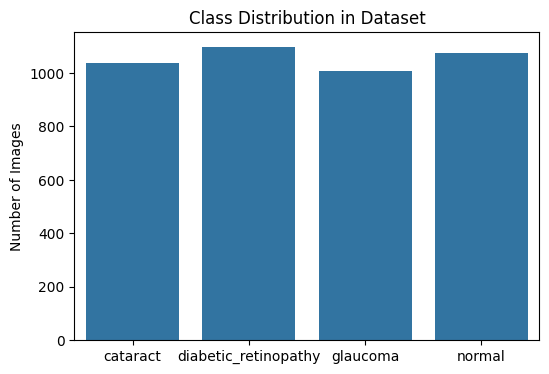

In [ ]:
# Count images per class
class_counts = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) for cls in classes}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution in Dataset")
plt.ylabel("Number of Images")
plt.show()


Sample visualization demonstrates how each preprocessing step transforms the image: Original → Wavelet → CLAHE → Vessel Mask -> Stacked Image.
Helps validate preprocessing quality visually.

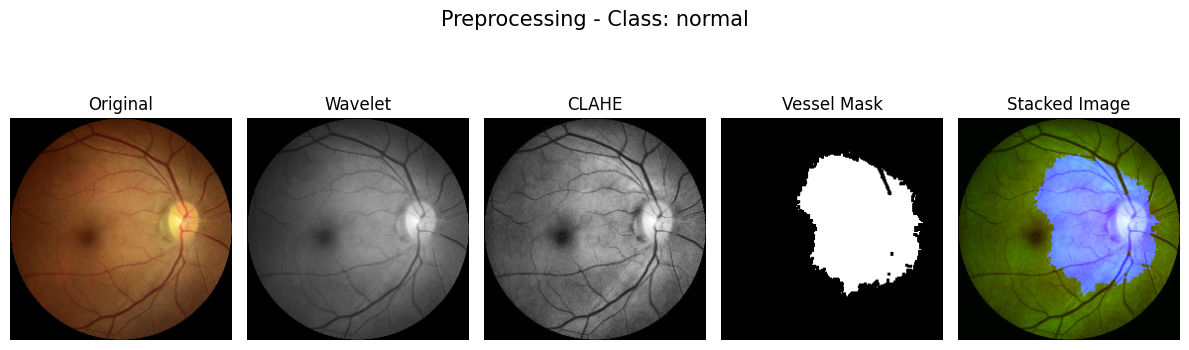

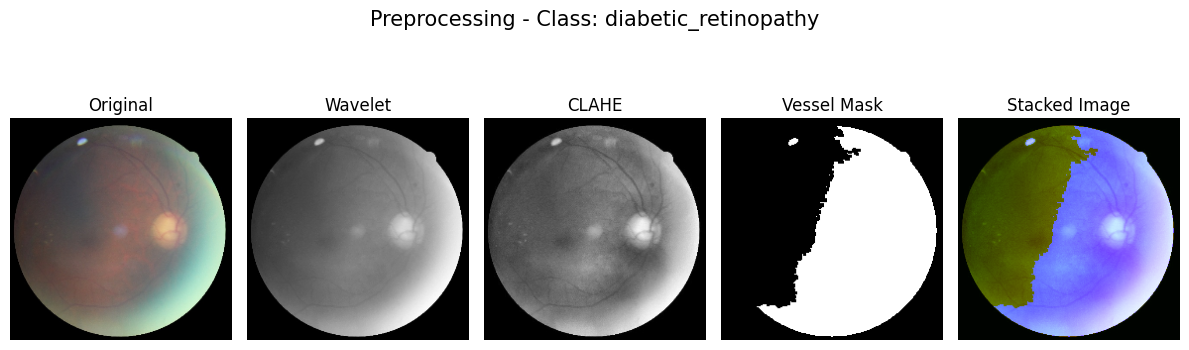

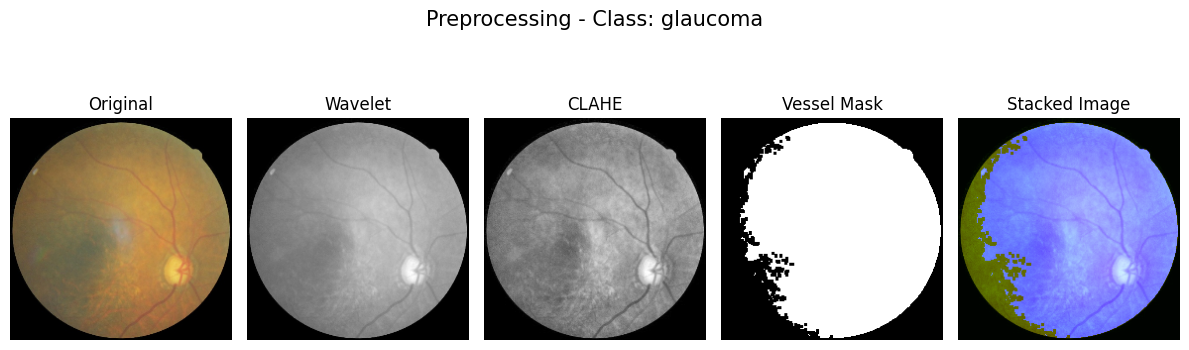

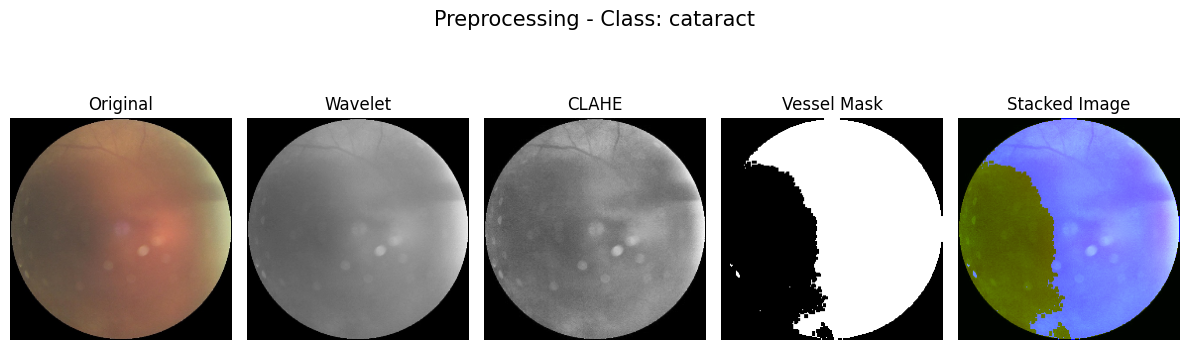

In [ ]:
def show_sample(class_name='normal'):
    sample_path = os.path.join(dataset_dir, class_name, os.listdir(os.path.join(dataset_dir, class_name))[0])
    img = cv2.imread(sample_path)
    img = cv2.resize(img, IMG_SIZE)

    # Apply preprocessing steps
    wavelet_img = wavelet_transform(img)            # Wavelet Transform
    clahe_img = apply_clahe(img)                    # CLAHE
    vessel_mask = blood_vessel_segmentation(img)    # Vessel Segmentation

    # Stack the three channels
    stacked_img = np.stack([wavelet_img, clahe_img, vessel_mask], axis=-1)
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Preprocessing - Class: {class_name}", fontsize=15)

    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(wavelet_img, cmap='gray')
    plt.title("Wavelet")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(clahe_img, cmap='gray')
    plt.title("CLAHE")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(vessel_mask, cmap='gray')
    plt.title("Vessel Mask")
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(stacked_img.astype('uint8'))
    plt.title("Stacked Image")
    plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_sample('normal')
show_sample('diabetic_retinopathy')
show_sample('glaucoma')
show_sample('cataract')


Box plot shows vessel intensity variation across classes.
Can reveal differences in vascular patterns among normal and diseased eyes.
Useful for exploratory data analysis (EDA) before modeling.

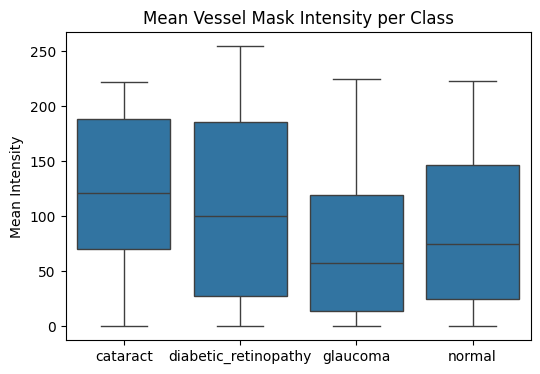

In [ ]:
# Feature Distribution Visualization
mean_intensity = []
class_labels = []

for cls in classes:
    vessel_dir = os.path.join(vessel_save_path, cls)
    for file in os.listdir(vessel_dir):
        mask = np.load(os.path.join(vessel_dir, file))
        mean_intensity.append(np.mean(mask))
        class_labels.append(cls)

plt.figure(figsize=(6, 4))
sns.boxplot(x=class_labels, y=mean_intensity)
plt.title("Mean Vessel Mask Intensity per Class")
plt.ylabel("Mean Intensity")
plt.show()


In [ ]:
#Feature Fusion and Extraction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Dataset Loader

class EyeDataset(Dataset):
    def __init__(self, image_dir, vessel_dir, classes, transform=None):
        self.samples = []
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        for cls in classes:
            img_cls_dir = os.path.join(image_dir, cls)
            ves_cls_dir = os.path.join(vessel_dir, cls)
            for f in os.listdir(img_cls_dir):
                if f.endswith('.npy'):
                    img_path = os.path.join(img_cls_dir, f)
                    ves_path = os.path.join(ves_cls_dir, f.replace('.npy', '_vessel.npy'))
                    self.samples.append((img_path, ves_path, self.class_to_idx[cls]))

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ves_path, label = self.samples[idx]
        img = np.load(img_path)
        vessel = np.load(ves_path)

        # Normalize
        img = img.astype(np.float32) / 255.0
        vessel = vessel.astype(np.float32) / 255.0

        # Convert to torch
        img = torch.tensor(img).permute(2,0,1)
        vessel = torch.tensor(vessel).unsqueeze(0)

        return img, vessel, label


**EFFICIENT NET B0 USING CROSS VALIDATION**

In [ ]:
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np
import os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of folds
n_splits = 5
print(f"Running {n_splits}-Fold Cross Validation on EfficientNet-B0...")

Running 5-Fold Cross Validation on EfficientNet-B0...


In [ ]:

# ----------------------------------------------------
# Prepare dataset for Stratified K-Fold
# ----------------------------------------------------
all_samples = []
all_labels = []

for cls_idx, cls in enumerate(classes):
    img_cls_dir = os.path.join(image_save_path, cls)
    ves_cls_dir = os.path.join(vessel_save_path, cls)
    for f in os.listdir(img_cls_dir):
        if f.endswith('.npy'):
            img_path = os.path.join(img_cls_dir, f)
            ves_path = os.path.join(ves_cls_dir, f.replace('.npy', '_vessel.npy'))
            all_samples.append((img_path, ves_path))
            all_labels.append(cls_idx)

all_samples = np.array(all_samples)
all_labels = np.array(all_labels)

In [ ]:
# ----------------------------------------------------
# Stratified K-Fold setup
# ----------------------------------------------------
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_results = []


In [ ]:
# ------------------ Cell 1: Train & Evaluate Function ------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

def train_evaluate_model(model, train_loader, val_loader, num_epochs=10, lr=1e-4):
    """
    Trains and evaluates a PyTorch model for a specified number of epochs.
    Returns: train_acc_list, val_acc_list, all_labels, all_preds, all_probs
    """

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_acc_list = []
    val_acc_list = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(num_epochs):
        # ---------------- TRAIN ----------------
        model.train()
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]"):
            if len(batch) == 3:
                imgs, _, labels = batch
            else:
                imgs, labels = batch

            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_acc_list.append(train_acc)

        # ---------------- VALIDATION ----------------
        model.eval()
        val_correct = 0
        val_total = 0
        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    imgs, _, labels = batch
                else:
                    imgs, labels = batch

                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(probs, 1)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        val_acc_list.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%")

    return train_acc_list, val_acc_list, all_labels, all_preds, all_probs


In [ ]:
# ------------------ Cell 2: Plotting Functions ------------------

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize

def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

def plot_learning_curve(train_acc, val_acc, title="Learning Curve"):
    plt.figure(figsize=(6,4))
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc(y_true, y_prob, classes, title="ROC Curve"):
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    plt.figure(figsize=(6,5))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()


**glucoma optimization trying**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
def train_evaluate_model(model, train_loader, val_loader, num_epochs=10, lr=1e-4):
    """
    Train & evaluate EfficientNet-B0 using weighted cross-entropy.
    """

    # Device must be defined first
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # ------------------ Compute class weights ------------------
    all_train_labels = []
    for batch in train_loader:
        if len(batch) == 3:
            _, _, labels = batch
        else:
            _, labels = batch
        all_train_labels.extend(labels.numpy())

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(classes)),
        y=np.array(all_train_labels)
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    print(f"\nClass Weights: {class_weights.cpu().numpy()}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # ------------------ Training & Validation Loop ------------------
    train_acc_list, val_acc_list = [], []
    for epoch in range(num_epochs):
        # Training
        model.train()
        correct, total = 0, 0
        for batch in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]"):
            if len(batch) == 3:
                imgs, _, labels = batch
            else:
                imgs, labels = batch
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        all_labels_fold, all_preds_fold, all_probs_fold = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    imgs, _, labels = batch
                else:
                    imgs, labels = batch
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(probs, 1)

                all_labels_fold.extend(labels.cpu().numpy())
                all_preds_fold.extend(preds.cpu().numpy())
                all_probs_fold.extend(probs.cpu().numpy())

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        val_acc_list.append(val_acc)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%")

    return train_acc_list, val_acc_list, all_labels_fold, all_preds_fold, all_probs_fold


In [ ]:
# ------------------ Cross Validation with Best Fold Saving ------------------

import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_splits = 5
best_val_acc_overall = 0.0
best_fold_overall = None
best_model_path = ""

print(f"Running {n_splits}-Fold Cross Validation with best fold saving...")

# Collect all samples and labels
all_samples, all_labels = [], []
for cls_idx, cls in enumerate(classes):
    img_cls_dir = os.path.join(image_save_path, cls)
    ves_cls_dir = os.path.join(vessel_save_path, cls)
    for f in os.listdir(img_cls_dir):
        if f.endswith('.npy'):
            img_path = os.path.join(img_cls_dir, f)
            ves_path = os.path.join(ves_cls_dir, f.replace('.npy', '_vessel.npy'))
            all_samples.append((img_path, ves_path))
            all_labels.append(cls_idx)

all_samples = np.array(all_samples)
all_labels = np.array(all_labels)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_samples, all_labels)):
    print(f"\n{'='*40}")
    print(f"Fold {fold + 1}/{n_splits}")
    print(f"{'='*40}")

    train_samples, val_samples = all_samples[train_idx], all_samples[val_idx]
    train_labels, val_labels = all_labels[train_idx], all_labels[val_idx]

    class FoldDataset(EyeDataset):
        def __init__(self, samples, labels, classes):
            self.samples = [(s[0], s[1], labels[i]) for i, s in enumerate(samples)]
            self.classes = classes

    train_dataset = FoldDataset(train_samples, train_labels, classes)
    val_dataset = FoldDataset(val_samples, val_labels, classes)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    # Model
    num_classes = len(classes)
    model_effnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
    model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, num_classes)
    model_effnet = model_effnet.to(device)

    # Train
    train_acc, val_acc, all_labels_fold, all_preds_fold, all_probs_fold = train_evaluate_model(
        model_effnet,
        train_loader,
        val_loader,
        num_epochs=10,
        lr=1e-4
    )

    fold_results.append({
        "fold": fold + 1,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "labels": all_labels_fold,
        "preds": all_preds_fold,
        "probs": all_probs_fold
    })

    # Save current fold model
    current_model_path = f'effnet_fold{fold+1}.pth'
    torch.save(model_effnet.state_dict(), current_model_path)
    print(f"Model for Fold {fold+1} saved as {current_model_path}")

    # Update best fold
    final_val_acc = val_acc[-1]  # last epoch
    if final_val_acc > best_val_acc_overall:
        best_val_acc_overall = final_val_acc
        best_fold_overall = fold + 1
        best_model_path = current_model_path
        print(f"--> Fold {fold+1} is currently the best fold!")

# ------------------ Summary ------------------
print(f"\n✅ Best Fold Overall: {best_fold_overall} with Validation Accuracy = {best_val_acc_overall:.2f}%")
print(f"Best model saved at: {best_model_path}")

# Optionally load the best model later
# model_effnet.load_state_dict(torch.load(best_model_path))
# model_effnet.eval()


Running 5-Fold Cross Validation with best fold saving...

Fold 1/5
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]



Class Weights: [1.0159639 0.9604214 1.0462159 0.9816647]


Epoch [1/10]: 100%|██████████| 106/106 [00:27<00:00,  3.84it/s]


Epoch [1/10]  Train Acc: 73.67%  Val Acc: 87.20%


...

Epoch [8/10]  Train Acc: 98.87%  Val Acc: 91.93%


Epoch [9/10]: 100%|██████████| 106/106 [00:26<00:00,  4.01it/s]


Epoch [9/10]  Train Acc: 99.17%  Val Acc: 92.05%


Epoch [10/10]: 100%|██████████| 106/106 [00:26<00:00,  4.03it/s]


Epoch [10/10]  Train Acc: 98.93%  Val Acc: 91.81%
Model for Fold 5 saved as effnet_fold5.pth

✅ Best Fold Overall: 4 with Validation Accuracy = 93.83%
Best model saved at: effnet_fold4.pth


In [ ]:
from sklearn.metrics import classification_report

# ------------------ Classification Report for Best Fold ------------------
print(f"\nGenerating classification report for Best Fold ({best_fold_overall})...")

# Get best fold results
best_fold_result = next(f for f in fold_results if f["fold"] == best_fold_overall)

# Extract labels and predictions
y_true = best_fold_result["labels"]
y_pred = best_fold_result["preds"]

# Print the classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)
print("\nClassification Report:")
print(report)



Generating classification report for Best Fold (4)...

Classification Report:
                      precision    recall  f1-score   support

            cataract     0.9563    0.9517    0.9540       207
diabetic_retinopathy     1.0000    1.0000    1.0000       220
            glaucoma     0.8846    0.9154    0.8998       201
              normal     0.9091    0.8837    0.8962       215

            accuracy                         0.9383       843
           macro avg     0.9375    0.9377    0.9375       843
        weighted avg     0.9386    0.9383    0.9383       843



In [ ]:
# ------------------ Cell: Per-Class Accuracy per Fold ------------------

print("\nPer-Class Accuracy for Each Fold:")
for fr in fold_results:
    labels = np.array(fr["labels"])
    preds = np.array(fr["preds"])
    print(f"\nFold {fr['fold']}:")
    for i, cls in enumerate(classes):
        cls_mask = labels == i
        cls_acc = 100 * np.sum(preds[cls_mask] == labels[cls_mask]) / np.sum(cls_mask)
        print(f"  {cls}: {cls_acc:.2f}%")



Per-Class Accuracy for Each Fold:

Fold 1:
  cataract: 95.67%
  diabetic_retinopathy: 99.55%
  glaucoma: 73.63%
  normal: 91.16%

Fold 2:
  cataract: 93.75%
  diabetic_retinopathy: 100.00%
  glaucoma: 77.72%
  normal: 92.09%

Fold 3:
  cataract: 90.38%
  diabetic_retinopathy: 100.00%
  glaucoma: 85.15%
  normal: 90.19%

Fold 4:
  cataract: 95.17%
  diabetic_retinopathy: 100.00%
  glaucoma: 91.54%
  normal: 88.37%

Fold 5:
  cataract: 90.34%
  diabetic_retinopathy: 99.09%
  glaucoma: 87.56%
  normal: 89.77%


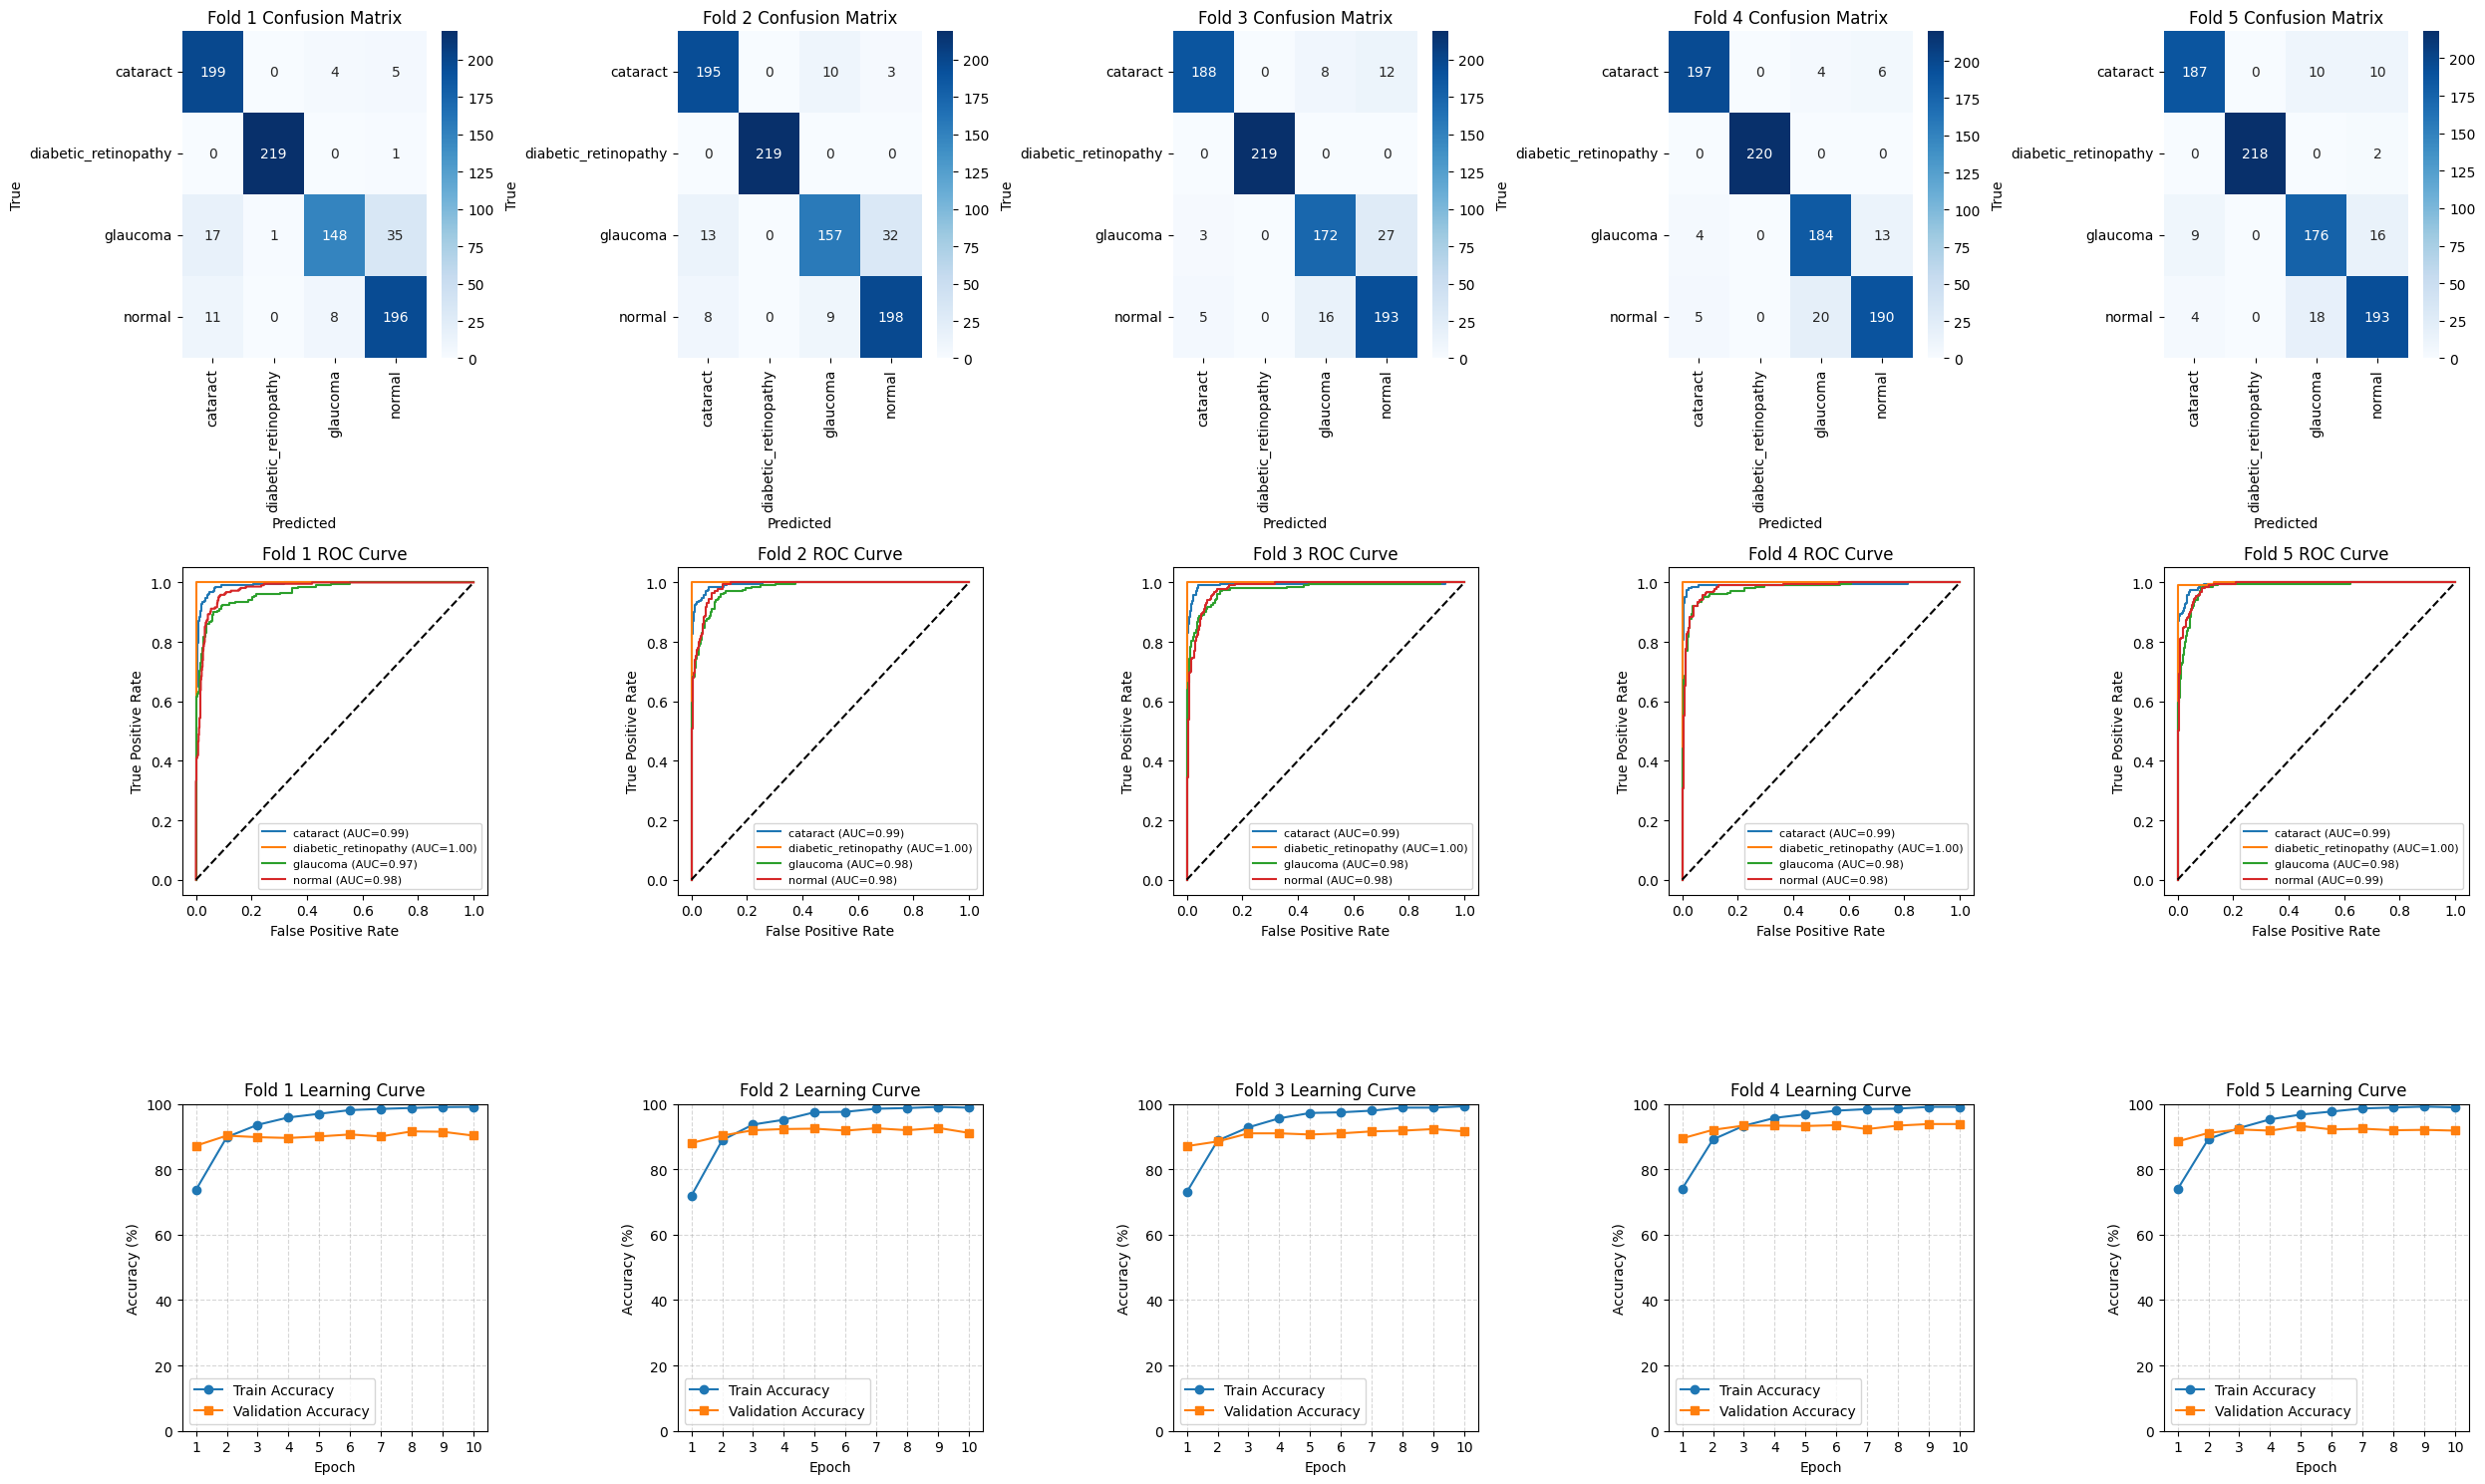

In [ ]:
# ------------------ Confusion Matrices + ROC + Learning Curves ------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

n_folds = len(fold_results)
fig, axes = plt.subplots(3, n_folds, figsize=(25, 15))  # 3 rows now

for i, fr in enumerate(fold_results):
    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(fr["labels"], fr["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                ax=axes[0, i])
    axes[0, i].set_title(f"Fold {fr['fold']} Confusion Matrix")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("True")

    # ---------------- ROC Curve ----------------
    y_true_bin = label_binarize(fr["labels"], classes=range(len(classes)))
    y_prob = np.array(fr["probs"])
    for j, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, j], y_prob[:, j])
        roc_auc = auc(fpr, tpr)
        axes[1, i].plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    axes[1, i].plot([0,1], [0,1], 'k--')
    axes[1, i].set_title(f"Fold {fr['fold']} ROC Curve")
    axes[1, i].set_xlabel("False Positive Rate")
    axes[1, i].set_ylabel("True Positive Rate")
    axes[1, i].legend(fontsize=8)

    # ---------------- Learning Curve ----------------
    train_acc = fr["train_acc"]
    val_acc = fr["val_acc"]
    epochs = range(1, len(train_acc)+1)

    axes[2, i].plot(epochs, train_acc, label="Train Accuracy", marker='o')
    axes[2, i].plot(epochs, val_acc, label="Validation Accuracy", marker='s')
    axes[2, i].set_title(f"Fold {fr['fold']} Learning Curve")
    axes[2, i].set_xlabel("Epoch")
    axes[2, i].set_ylabel("Accuracy (%)")
    axes[2, i].set_xticks(epochs)
    axes[2, i].set_ylim(0, 100)
    axes[2, i].grid(True, linestyle='--', alpha=0.5)
    axes[2, i].legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("\n📊 Classification Report for Each Fold:\n")

for fr in fold_results:
    y_true = fr["labels"]
    y_pred = fr["preds"]
    print(f"\n================ Fold {fr['fold']} ================")
    print(classification_report(y_true, y_pred, target_names=classes))



📊 Classification Report for Each Fold:


================ Fold 1 ================
                      precision    recall  f1-score   support

            cataract       0.88      0.96      0.91       208
diabetic_retinopathy       1.00      1.00      1.00       220
            glaucoma       0.93      0.74      0.82       201
              normal       0.83      0.91      0.87       215

            accuracy                           0.90       844
           macro avg       0.91      0.90      0.90       844
        weighted avg       0.91      0.90      0.90       844


================ Fold 2 ================
                      precision    recall  f1-score   support

            cataract       0.90      0.94      0.92       208
diabetic_retinopathy       1.00      1.00      1.00       219
            glaucoma       0.89      0.78      0.83       202
              normal       0.85      0.92      0.88       215

            accuracy                           0.91       844
  

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model architecture
num_classes = len(classes)
model_effnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
model_effnet.classifier[1] = nn.Linear(model_effnet.classifier[1].in_features, num_classes)

# Load the trained weights for Fold 5
fold_num = 5
model_path = f'effnet_fold{fold_num}.pth'

# Load model weights
state_dict = torch.load(model_path, map_location=device)
model_effnet.load_state_dict(state_dict)

# Move model to device and set to evaluation mode
model_effnet = model_effnet.to(device)
model_effnet.eval()

print(f"✅ EfficientNet-B0 model from Fold {fold_num} loaded successfully and ready for inference.")


✅ EfficientNet-B0 model from Fold 5 loaded successfully and ready for inference.


Xai Techniques on Efficientnet B0

dice


🔍 Dice Coefficient for class: cataract


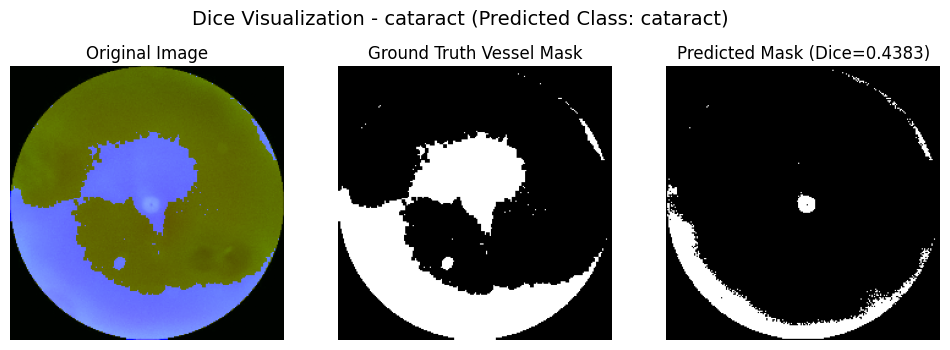


🔍 Dice Coefficient for class: diabetic_retinopathy


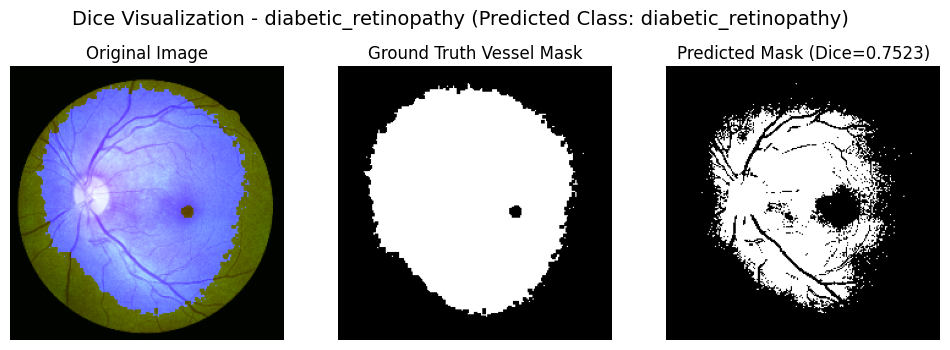


🔍 Dice Coefficient for class: glaucoma


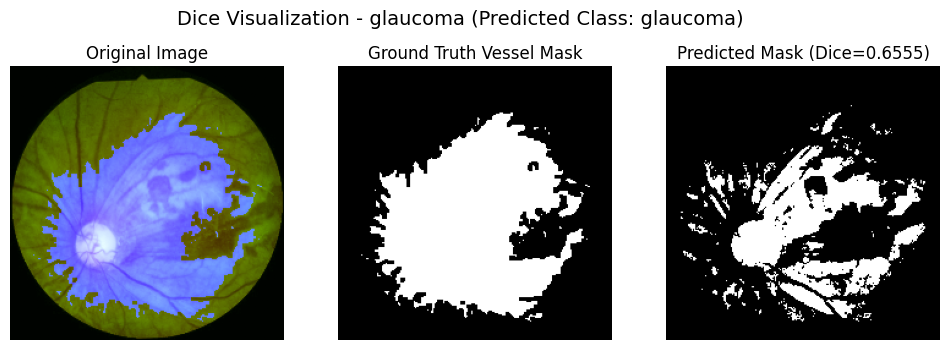


🔍 Dice Coefficient for class: normal


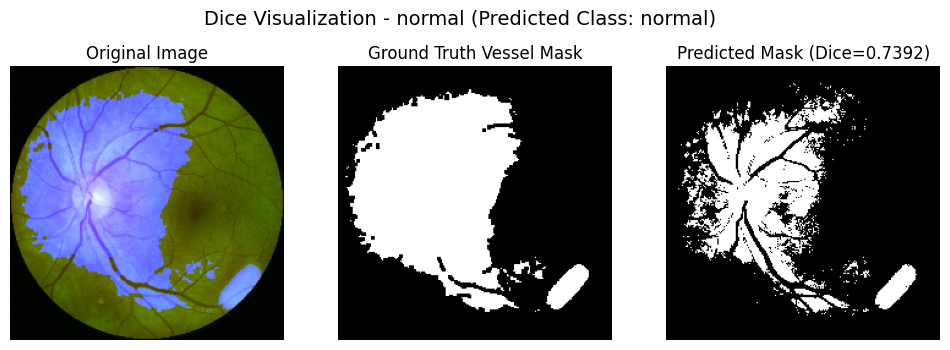

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dice function
def dice_coefficient(pred_mask, gt_mask, smooth=1e-6):
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    intersection = np.sum(pred_flat * gt_flat)
    dice = (2. * intersection + smooth) / (np.sum(pred_flat) + np.sum(gt_flat) + smooth)
    return dice

# Pick one sample per class
for class_name in classes:
    print(f"\n🔍 Dice Coefficient for class: {class_name}")

    # Load one sample image & vessel mask
    sample_img_path = os.path.join(image_save_path, class_name, os.listdir(os.path.join(image_save_path, class_name))[0])
    sample_vessel_path = os.path.join(vessel_save_path, class_name, os.listdir(os.path.join(vessel_save_path, class_name))[0])

    img = np.load(sample_img_path).astype(np.float32)/255.0
    gt_vessel = np.load(sample_vessel_path).astype(np.float32)/255.0

    # Convert to torch tensor for model input
    img_tensor = torch.tensor(img).unsqueeze(0).permute(0,3,1,2).to(device)  # [1,C,H,W]

    # Get model output (probabilities for classes)
    with torch.no_grad():
        model_effnet.eval()
        outputs = model_effnet(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    # Simple proxy mask: threshold the green channel from preprocessed image
    pred_mask = img[:,:,1] > 0.5  # Binary mask
    pred_mask = pred_mask.astype(np.float32)

    dice_score = dice_coefficient(pred_mask, gt_vessel)

    # Visualize
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img[:,:,:3])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt_vessel, cmap="gray")
    plt.title("Ground Truth Vessel Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title(f"Predicted Mask (Dice={dice_score:.4f})")
    plt.axis("off")

    plt.suptitle(f"Dice Visualization - {class_name} (Predicted Class: {classes[pred_class]})", fontsize=14)
    plt.show()


LIME

In [ ]:
!pip install lime scikit-image


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d485b99bcf4e876c9dbbe7636b25f5366a2f86c04fe4d40cefecd5cca70161b8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


✅ Using the same fixed image per class:
cataract: /content/drive/MyDrive/eye_diseases_classification/dataset/cataract/0_left.jpg
diabetic_retinopathy: /content/drive/MyDrive/eye_diseases_classification/dataset/diabetic_retinopathy/10003_left.jpeg
glaucoma: /content/drive/MyDrive/eye_diseases_classification/dataset/glaucoma/1020_left.jpg
normal: /content/drive/MyDrive/eye_diseases_classification/dataset/normal/1034_left.jpg

🔍 Generating LIME for class: cataract


  0%|          | 0/1000 [00:00<?, ?it/s]


🔍 Generating LIME for class: diabetic_retinopathy


  0%|          | 0/1000 [00:00<?, ?it/s]


🔍 Generating LIME for class: glaucoma


  0%|          | 0/1000 [00:00<?, ?it/s]


🔍 Generating LIME for class: normal


  0%|          | 0/1000 [00:00<?, ?it/s]

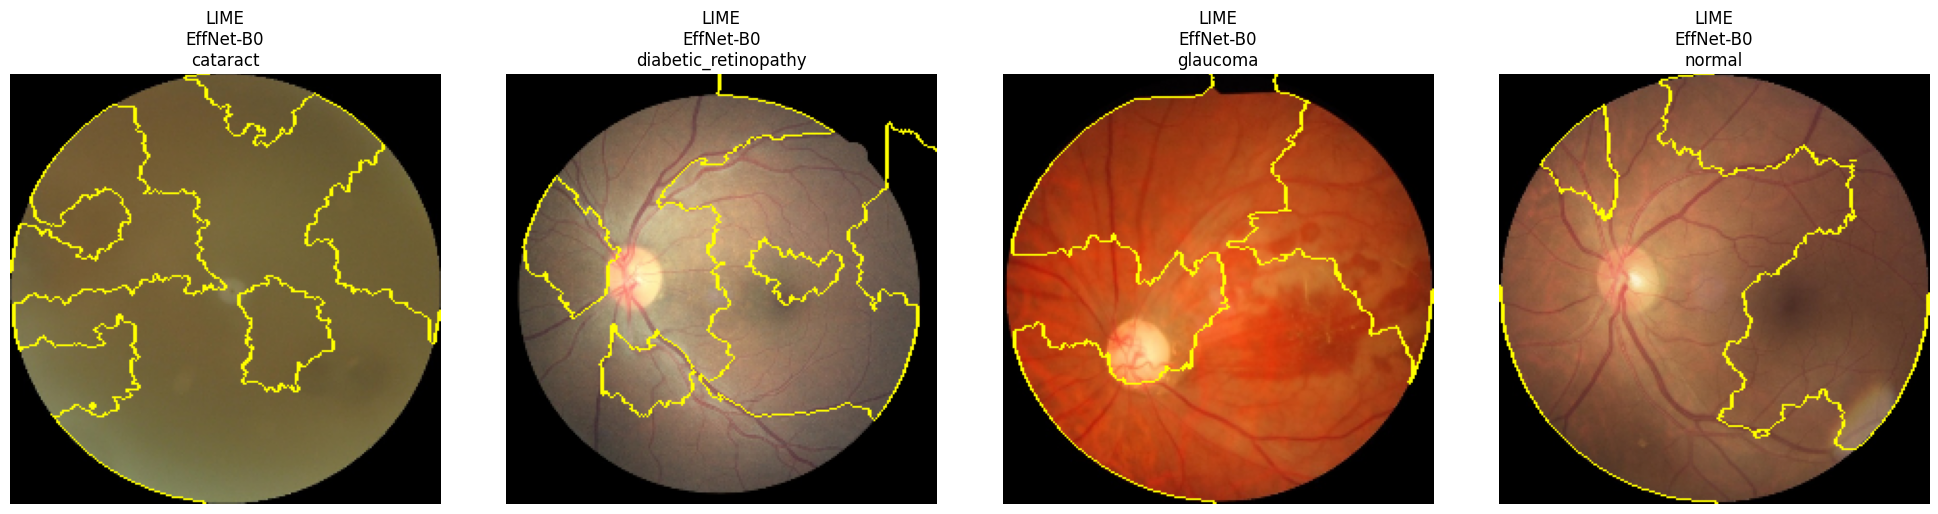

In [ ]:
# ==============================================
# ✅ LIME Explainability for EfficientNet-B0 (One Row Display)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

def tensor_to_img(tensor):
    img = tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img

def predict_fn(images, model):
    model.eval()
    images_t = []
    for img in images:
        img_t = torch.tensor(img.transpose(2, 0, 1)).unsqueeze(0).float() / 255.0
        images_t.append(img_t)
    images_t = torch.cat(images_t).to(device)
    with torch.no_grad():
        outputs = model(images_t)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

sample_images = {}
for class_name in classes:
    class_dir = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    sample_file = files[0]
    sample_images[class_name] = os.path.join(class_dir, sample_file)

print("✅ Using the same fixed image per class:")
for k, v in sample_images.items():
    print(f"{k}: {v}")

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(1, len(classes), figsize=(20,5))

for idx, class_name in enumerate(classes):
    print(f"\n🔍 Generating LIME for class: {class_name}")

    sample_path = sample_images[class_name]
    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_np = np.array(img_rgb)

    explanation_effnet = explainer.explain_instance(
        image=img_np,
        classifier_fn=lambda x: predict_fn(x, model_effnet),
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation_effnet.get_image_and_mask(
        label=explanation_effnet.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    axes[idx].imshow(mark_boundaries(temp/255.0, mask))
    axes[idx].set_title(f"LIME\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Grad-CAM

✅ Using the same fixed image per class:
cataract: /content/drive/MyDrive/eye_diseases_classification/dataset/cataract/0_left.jpg
diabetic_retinopathy: /content/drive/MyDrive/eye_diseases_classification/dataset/diabetic_retinopathy/10003_left.jpeg
glaucoma: /content/drive/MyDrive/eye_diseases_classification/dataset/glaucoma/1020_left.jpg
normal: /content/drive/MyDrive/eye_diseases_classification/dataset/normal/1034_left.jpg

🔥 Generating Grad-CAM for class: cataract

🔥 Generating Grad-CAM for class: diabetic_retinopathy

🔥 Generating Grad-CAM for class: glaucoma

🔥 Generating Grad-CAM for class: normal


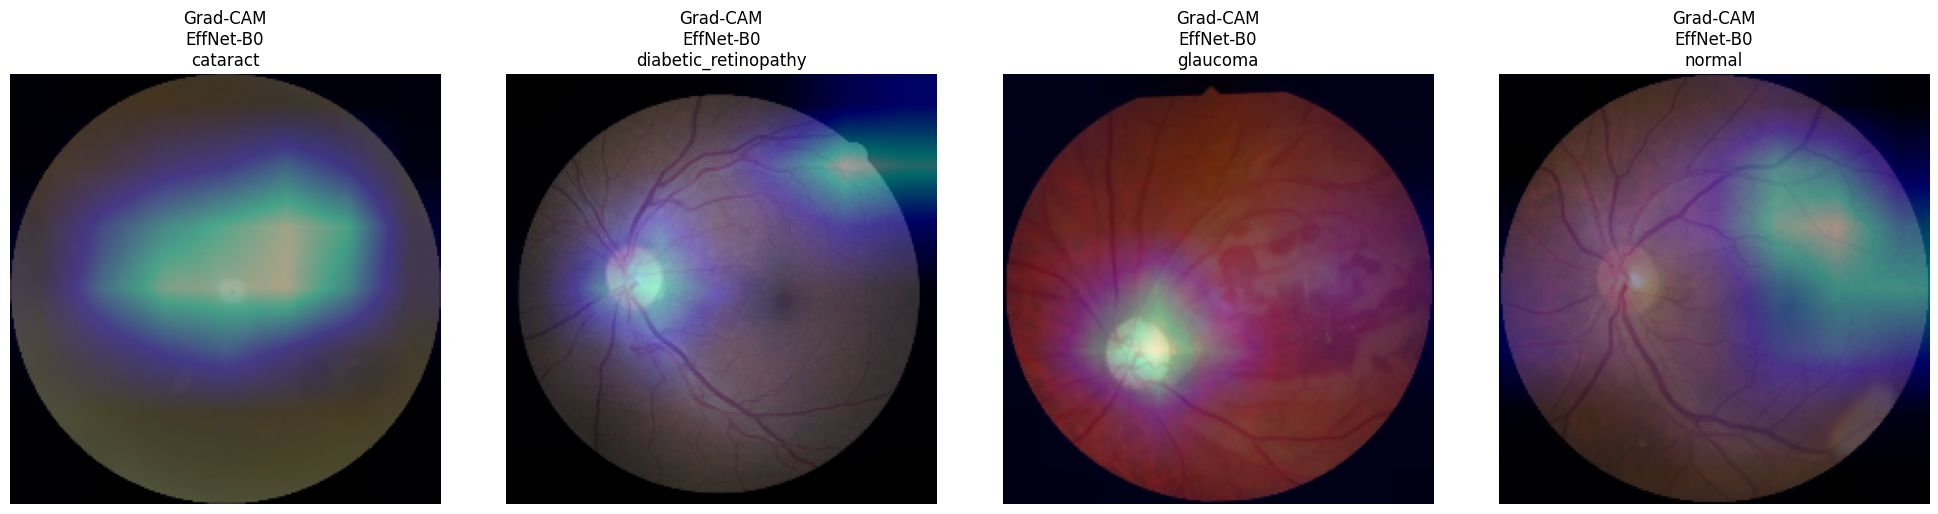

In [ ]:
# ==============================================
# ✅ Grad-CAM Explainability for EfficientNet-B0 (One Row Display)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import LayerGradCam
from torchvision import transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

def tensor_to_img(tensor):
    img = tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def overlay_heatmap_on_image(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)
    overlay = cv2.addWeighted(heatmap_colored, alpha, image, 1 - alpha, 0)
    return overlay

sample_images = {}
for class_name in classes:
    class_dir = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    sample_file = files[0]
    sample_images[class_name] = os.path.join(class_dir, sample_file)

print("✅ Using the same fixed image per class:")
for k, v in sample_images.items():
    print(f"{k}: {v}")

fig, axes = plt.subplots(1, len(classes), figsize=(20,5))

for idx, class_name in enumerate(classes):
    print(f"\n🔥 Generating Grad-CAM for class: {class_name}")

    sample_path = sample_images[class_name]
    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    transform = transforms.Compose([transforms.ToTensor()])
    sample_img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    sample_label = classes.index(class_name)

    target_layer = model_effnet.features[-1]
    gradcam = LayerGradCam(model_effnet, target_layer)
    attr_gc = gradcam.attribute(sample_img_tensor, target=sample_label)

    heatmap_gc = attr_gc[0].sum(dim=0).cpu().detach().numpy()
    heatmap_gc = (heatmap_gc - heatmap_gc.min()) / (heatmap_gc.max() - heatmap_gc.min() + 1e-8)

    superimposed_gc = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap_gc, alpha=0.4, colormap=cv2.COLORMAP_HOT)

    axes[idx].imshow(superimposed_gc)
    axes[idx].set_title(f"Grad-CAM\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Integrated Gradients

✅ Using the same fixed image per class:
cataract: /content/drive/MyDrive/eye_diseases_classification/dataset/cataract/0_left.jpg
diabetic_retinopathy: /content/drive/MyDrive/eye_diseases_classification/dataset/diabetic_retinopathy/10003_left.jpeg
glaucoma: /content/drive/MyDrive/eye_diseases_classification/dataset/glaucoma/1020_left.jpg
normal: /content/drive/MyDrive/eye_diseases_classification/dataset/normal/1034_left.jpg

⚡ Integrated Gradients - class: cataract

⚡ Integrated Gradients - class: diabetic_retinopathy

⚡ Integrated Gradients - class: glaucoma

⚡ Integrated Gradients - class: normal


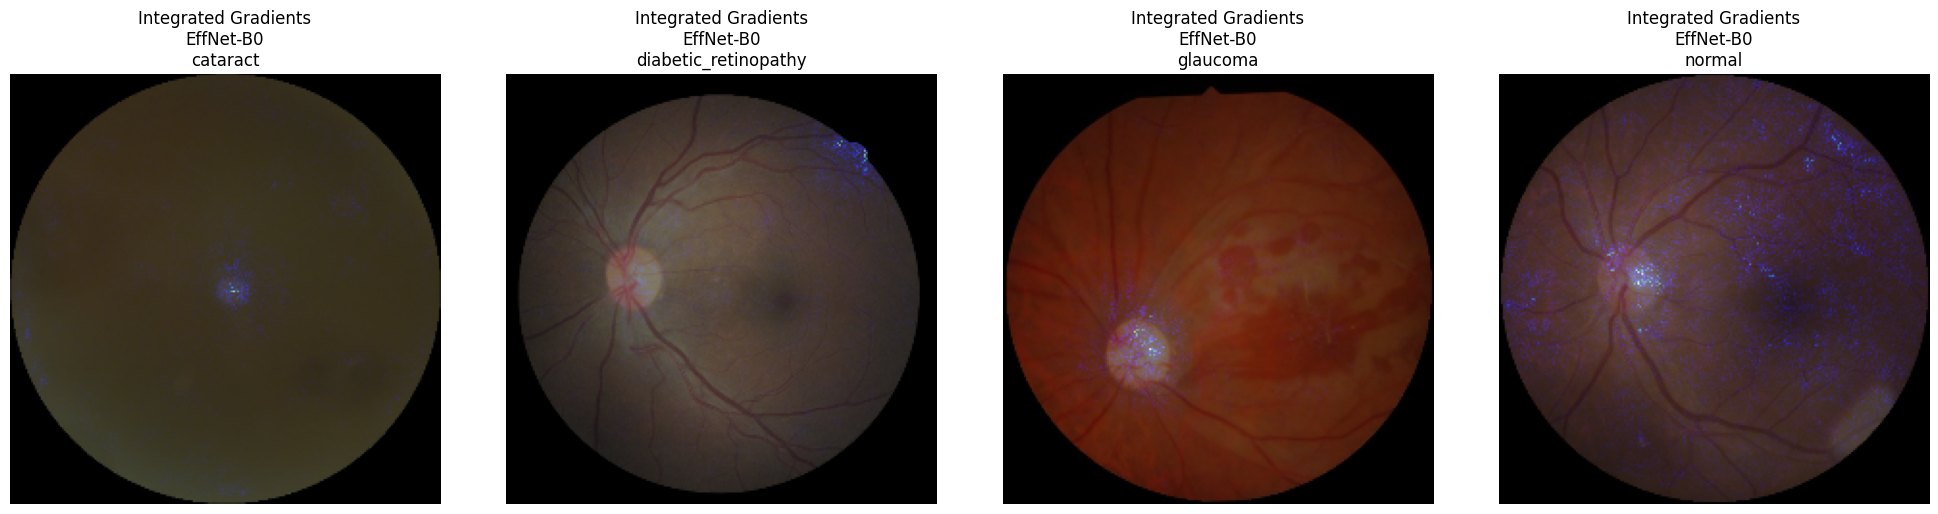

In [ ]:
# ==============================================
# ✅ Integrated Gradients for EfficientNet-B0 (One Row Display)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import IntegratedGradients
from torchvision import transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

def overlay_heatmap_on_image(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)
    overlay = cv2.addWeighted(heatmap_colored, alpha, image, 1 - alpha, 0)
    return overlay

sample_images = {}
for class_name in classes:
    class_dir = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    sample_file = files[0]
    sample_images[class_name] = os.path.join(class_dir, sample_file)

print("✅ Using the same fixed image per class:")
for k, v in sample_images.items():
    print(f"{k}: {v}")

ig = IntegratedGradients(model_effnet)
transform = transforms.Compose([transforms.ToTensor()])

fig, axes = plt.subplots(1, len(classes), figsize=(20,5))

for idx, class_name in enumerate(classes):
    print(f"\n⚡ Integrated Gradients - class: {class_name}")

    sample_path = sample_images[class_name]
    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    sample_img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    sample_label = classes.index(class_name)

    attr_ig = ig.attribute(sample_img_tensor, target=sample_label, n_steps=50)

    heatmap = np.abs(attr_ig[0].cpu().detach().numpy()).sum(axis=0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    superimposed_ig = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap, alpha=0.5)

    axes[idx].imshow(superimposed_ig)
    axes[idx].set_title(f"Integrated Gradients\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Saliency Map


🔍 Saliency Map for class: cataract

🔍 Saliency Map for class: diabetic_retinopathy

🔍 Saliency Map for class: glaucoma


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)



🔍 Saliency Map for class: normal


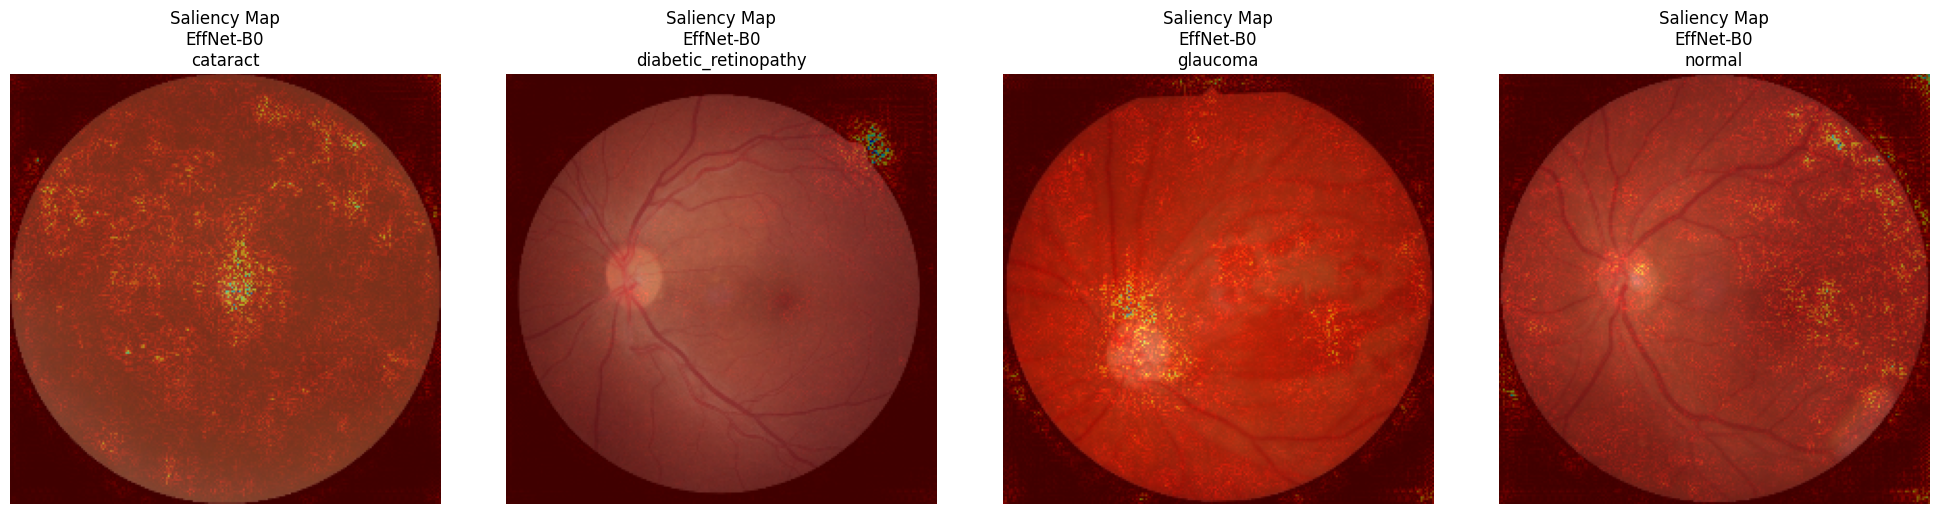

In [ ]:
# ==============================================
# ✅ Saliency Map Explainability for EfficientNet-B0 (One Row Display)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import Saliency
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

def overlay_heatmap_on_image(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), colormap)
    heatmap_colored = cv2.resize(heatmap_colored, (image.shape[1], image.shape[0]))
    overlay = cv2.addWeighted(heatmap_colored, alpha, image, 1 - alpha, 0)
    return overlay

fig, axes = plt.subplots(1, len(classes), figsize=(20,5))

for idx, class_name in enumerate(classes):
    print(f"\n🔍 Saliency Map for class: {class_name}")

    class_dir = os.path.join(dataset_dir, class_name)
    sample_file = sorted([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])[0]
    sample_path = os.path.join(class_dir, sample_file)

    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_tensor = torch.tensor(img_rgb.transpose(2,0,1)).unsqueeze(0).float() / 255.0
    img_tensor = img_tensor.to(device)

    sample_label = classes.index(class_name)

    saliency = Saliency(model_effnet)
    attr_saliency = saliency.attribute(img_tensor, target=sample_label)

    heatmap_saliency = attr_saliency[0].abs().sum(dim=0).cpu().detach().numpy()
    heatmap_saliency = (heatmap_saliency - heatmap_saliency.min()) / (heatmap_saliency.max() - heatmap_saliency.min() + 1e-8)

    superimposed_saliency = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap_saliency, alpha=0.5)

    axes[idx].imshow(superimposed_saliency)
    axes[idx].set_title(f"Saliency Map\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Occlusion Sensitivity

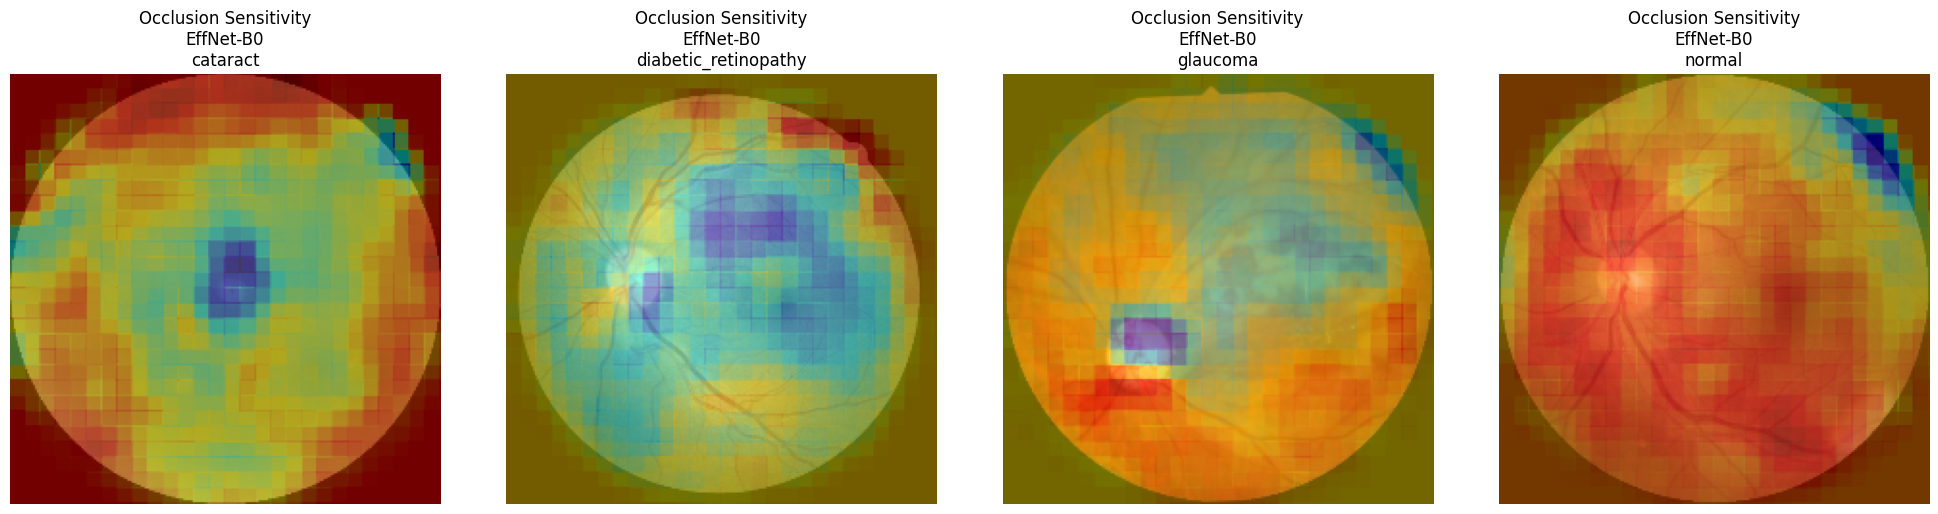

In [ ]:
# ==============================================
# ✅ Occlusion Sensitivity for EfficientNet-B0 (One Row Plot)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import Occlusion
from torchvision import transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

# Helper: Overlay heatmap on image
def overlay_heatmap_on_image(image, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), colormap)
    heatmap_on_img = cv2.addWeighted(image, 1 - alpha, heatmap_colored, alpha, 0)
    return heatmap_on_img

# Fixed sample image per class
sample_images = {}
for class_name in classes:
    class_dir = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    sample_images[class_name] = os.path.join(class_dir, files[0])

occlusion = Occlusion(model_effnet)

# -------------------------------
# Compute heatmaps for all classes
# -------------------------------
heatmaps = []
for class_name in classes:
    img_path = sample_images[class_name]

    # Load and preprocess
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    transform = transforms.Compose([transforms.ToTensor()])
    img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    target_label = classes.index(class_name)

    # Compute Occlusion
    attr_occ = occlusion.attribute(
        img_tensor,
        target=target_label,
        sliding_window_shapes=(3, 15, 15),
        strides=(3, 8, 8),
    )

    heatmap = attr_occ[0].sum(dim=0).cpu().detach().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-10)
    result = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap)

    heatmaps.append((result, class_name))

# -------------------------------
# Display all heatmaps in a single row
# -------------------------------
plt.figure(figsize=(5 * len(classes), 5))
for i, (img, class_name) in enumerate(heatmaps):
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(f"Occlusion Sensitivity\nEffNet-B0\n{class_name}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()


Guided Backpropagation


✅ Guided Backprop will use the same fixed sample per class:
cataract -> /content/drive/MyDrive/eye_diseases_classification/dataset/cataract/0_left.jpg
diabetic_retinopathy -> /content/drive/MyDrive/eye_diseases_classification/dataset/diabetic_retinopathy/10003_left.jpeg
glaucoma -> /content/drive/MyDrive/eye_diseases_classification/dataset/glaucoma/1020_left.jpg
normal -> /content/drive/MyDrive/eye_diseases_classification/dataset/normal/1034_left.jpg


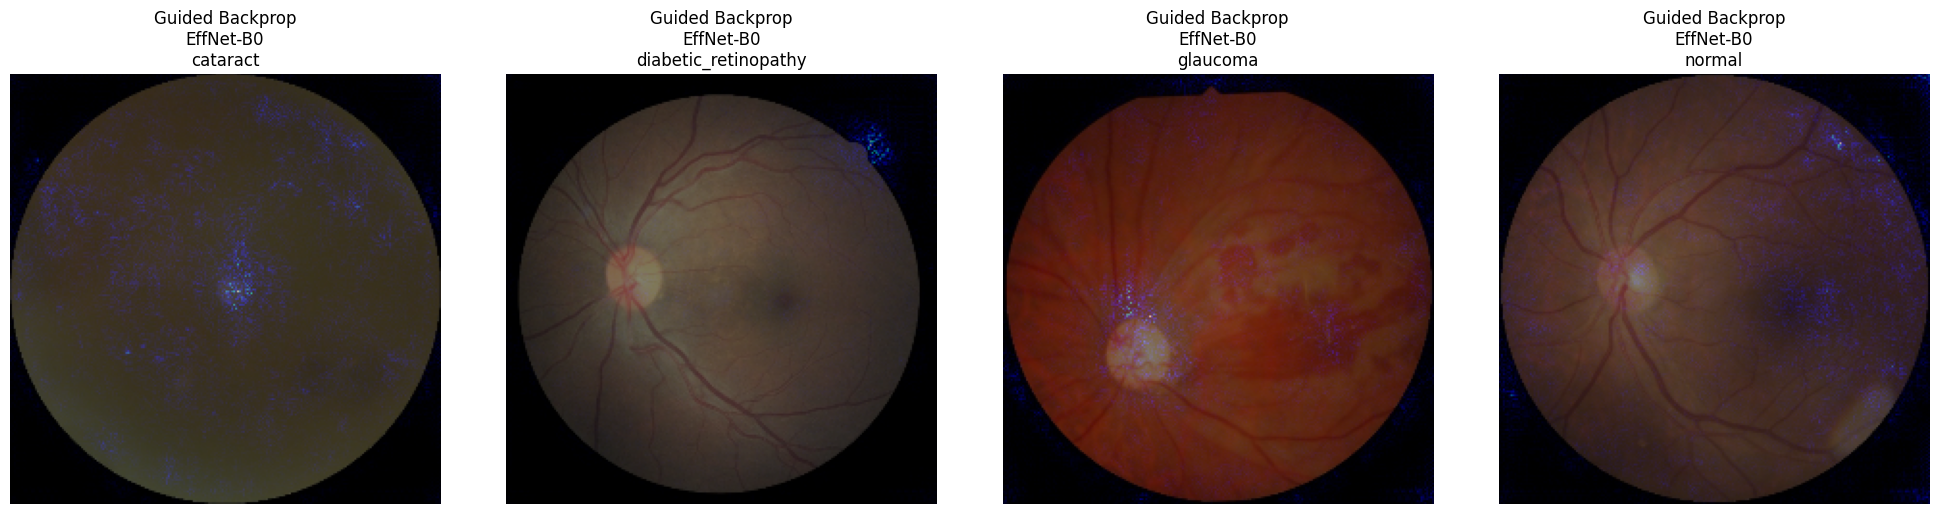

In [ ]:
# ==============================================
# ✅ Guided Backpropagation for EfficientNet-B0 (One Row Plot)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import GuidedBackprop
from torchvision import transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

# Helper: Overlay heatmap on image
def overlay_heatmap_on_image(image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)
    blended = cv2.addWeighted(heatmap_colored, alpha, image, 1 - alpha, 0)
    return blended

# Fixed sample per class
sample_images = {}
for class_name in classes:
    class_path = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    sample_images[class_name] = os.path.join(class_path, files[0])

print("\n✅ Guided Backprop will use the same fixed sample per class:")
for k, v in sample_images.items():
    print(f"{k} -> {v}")

gbp = GuidedBackprop(model_effnet)
transform = transforms.Compose([transforms.ToTensor()])

# -------------------------------
# Plot all classes in a single row
# -------------------------------
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

for idx, class_name in enumerate(classes):
    sample_path = sample_images[class_name]

    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    target_label = classes.index(class_name)

    attr = gbp.attribute(img_tensor, target=target_label)
    heatmap = np.abs(attr[0].cpu().detach().numpy()).sum(axis=0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-10)

    guided_map = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap)

    axes[idx].imshow(guided_map)
    axes[idx].set_title(f"Guided Backprop\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Gradient SHAP

✅ Using fixed image for each class:
cataract: /content/drive/MyDrive/eye_diseases_classification/dataset/cataract/0_left.jpg
diabetic_retinopathy: /content/drive/MyDrive/eye_diseases_classification/dataset/diabetic_retinopathy/10003_left.jpeg
glaucoma: /content/drive/MyDrive/eye_diseases_classification/dataset/glaucoma/1020_left.jpg
normal: /content/drive/MyDrive/eye_diseases_classification/dataset/normal/1034_left.jpg

⚡ Gradient SHAP - class: cataract

⚡ Gradient SHAP - class: diabetic_retinopathy

⚡ Gradient SHAP - class: glaucoma

⚡ Gradient SHAP - class: normal


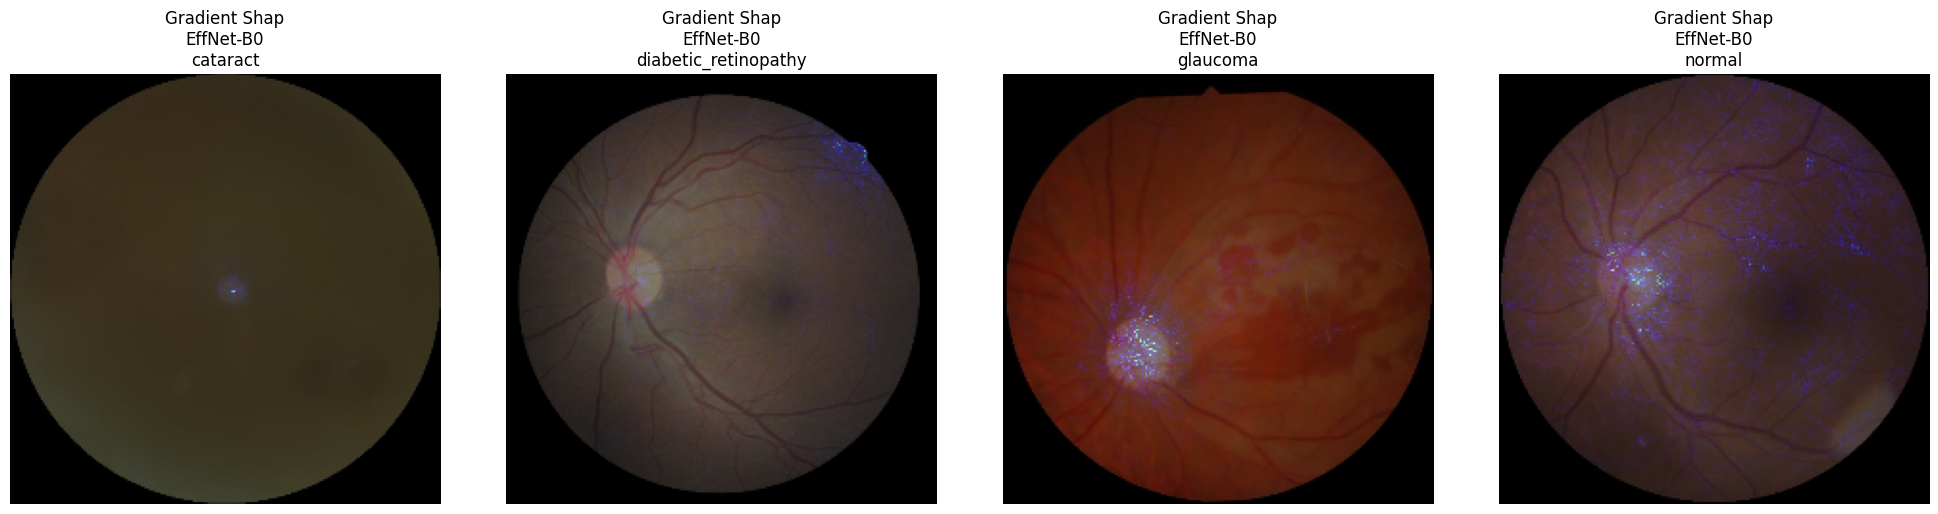

In [ ]:
# ==============================================
# ✅ Gradient SHAP for EfficientNet-B0 (One Row Plot)
# ==============================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from captum.attr import GradientShap
from torchvision import transforms
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_effnet.eval()

# Helper: Overlay heatmap on image
def overlay_heatmap_on_image(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_HOT):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)
    overlay = cv2.addWeighted(heatmap_colored, alpha, image, 1 - alpha, 0)
    return overlay

sample_images = {}
for class_name in classes:
    class_dir = os.path.join(dataset_dir, class_name)
    files = sorted([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    sample_file = files[0]
    sample_images[class_name] = os.path.join(class_dir, sample_file)

print("✅ Using fixed image for each class:")
for k, v in sample_images.items():
    print(f"{k}: {v}")

gs = GradientShap(model_effnet)
transform = transforms.Compose([transforms.ToTensor()])

fig, axes = plt.subplots(1, len(classes), figsize=(20,5))

for idx, class_name in enumerate(classes):
    print(f"\n⚡ Gradient SHAP - class: {class_name}")

    sample_path = sample_images[class_name]
    img = cv2.imread(sample_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    sample_img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    sample_label = classes.index(class_name)

    baselines = torch.zeros_like(sample_img_tensor).to(device)

    attr_gs = gs.attribute(
        sample_img_tensor,
        baselines=baselines,
        target=sample_label,
        n_samples=50,
        stdevs=0.01
    )

    heatmap = attr_gs[0].cpu().detach().numpy()
    heatmap = np.sum(np.abs(heatmap), axis=0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)

    superimposed_gs = overlay_heatmap_on_image(np.uint8(img_rgb), heatmap, alpha=0.5, colormap=cv2.COLORMAP_HOT)

    axes[idx].imshow(superimposed_gs)
    axes[idx].set_title(f"Gradient Shap\nEffNet-B0\n{class_name}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()
